# CAPSTONE PROJECT 1
## Working with NumPy Matrices (Multidimensional Data)

## Submitted By:
Rithya Reddy

## Internship:
IBM SkillsBuild / Corizo

## Objective:
To analyze NHANES body measurement data of adult males and females using NumPy, Pandas, and Matplotlib.
The project explores body measurements such as weight, height, arm circumference, hip circumference, waist circumference, and Body Mass Index (BMI). Statistical analysis and visualization techniques are used to identify patterns and relationships within the data.

## Importing Required Libraries

The following libraries are used throughout the analysis:

- NumPy for numerical computations
- Pandas for data handling
- Matplotlib for visualization
- SciPy for statistical measures

In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew
from pandas.plotting import scatter_matrix

## 1. Downloading the dataset

From https://github.com/gagolews/teaching-data/tree/master/marek download the two following excerpts from the National Health and Nutrition Examination Survey ( NHANES dataset ):

1) nhanes_adult_male_bmx_2020.csv,

2) nhanes_adult_female_bmx_2020.csv.

They give body measurements of adult males and females.

## Loading the NHANES Dataset

The NHANES body measurement datasets for adult male and female participants are loaded into Pandas DataFrames.

The files contain descriptive comment lines beginning with the '#' character. Therefore, the `comment='#'` parameter is used to ignore these lines while reading the data.

The original variable names (e.g., BMXWT, BMXHT) are then replaced with more descriptive column names such as Weight and Height to improve readability and facilitate analysis throughout the project.

In [155]:
import os
print(os.listdir())

['desktop.ini', 'HACKATHON 1ST WINNER 2-1.pdf', 'minor_project.ipynb', 'nhanes_adult_female_bmx_2020.csv', 'nhanes_adult_male_bmx_2020.csv', 'Rithya reddy - Chrome.lnk', 'Rithya Reddy CPD-3.png', 'rithya resume.docx']


In [156]:
import pandas as pd

male_df = pd.read_csv(
    "nhanes_adult_male_bmx_2020.csv",
    comment="#"
)

female_df = pd.read_csv(
    "nhanes_adult_female_bmx_2020.csv",
    comment="#"
)

In [157]:
male_df.columns = [
    "Weight",
    "Height",
    "Upper_Arm_Length",
    "Upper_Leg_Length",
    "Arm_Circumference",
    "Hip_Circumference",
    "Waist_Circumference"
]

female_df.columns = male_df.columns

In [158]:
print(male_df.head())
print(male_df.dtypes)
print(male_df.shape)

   Weight  Height  Upper_Arm_Length  Upper_Leg_Length  Arm_Circumference  \
0    98.8   182.3              42.0              40.1               38.2   
1    74.3   184.2              41.1              41.0               30.2   
2   103.7   185.3              47.0              44.0               32.0   
3    86.0   167.8              39.5              38.4               29.0   
4    99.4   181.6              40.4              39.9               36.0   

   Hip_Circumference  Waist_Circumference  
0              108.2                120.4  
1               94.5                 86.8  
2              107.8                109.6  
3              106.4                108.3  
4              120.2                107.0  
Weight                 float64
Height                 float64
Upper_Arm_Length       float64
Upper_Leg_Length       float64
Arm_Circumference      float64
Hip_Circumference      float64
Waist_Circumference    float64
dtype: object
(4081, 7)


In [159]:
print(female_df.head())
print(female_df.dtypes)
print(female_df.shape)

   Weight  Height  Upper_Arm_Length  Upper_Leg_Length  Arm_Circumference  \
0    97.1   160.2              34.7              40.8               35.8   
1    91.1   152.7              33.5              33.0               38.5   
2    73.0   161.2              37.4              38.0               31.8   
3    61.7   157.4              38.0              34.7               29.0   
4    55.4   154.6              34.6              34.0               28.3   

   Hip_Circumference  Waist_Circumference  
0              126.1                117.9  
1              125.5                103.1  
2              106.2                 92.0  
3              101.0                 90.5  
4               92.5                 73.2  
Weight                 float64
Height                 float64
Upper_Arm_Length       float64
Upper_Leg_Length       float64
Arm_Circumference      float64
Hip_Circumference      float64
Waist_Circumference    float64
dtype: object
(4221, 7)


### Observation

The datasets were loaded successfully. All seven body measurements are numerical variables, making them suitable for statistical analysis and visualization. Descriptive column names were assigned to improve clarity throughout the project.

## 2. Converting DataFrames to NumPy Matrices

Since the project focuses on NumPy matrices, the Pandas DataFrames are converted into NumPy arrays.

Read the two files as numpy matrices named male and female. Each matrix consists of seven columns:
1. weight (kg),
2. standing height (cm),
3. upper arm length (cm),
4. upper leg length (cm),
5. arm circumference(cm),
6. hip circumference(cm),
7. waist circumference(cm).

In [160]:
male = male_df.to_numpy()
female = female_df.to_numpy()

In [161]:
print(male.shape)
print(female.shape)

(4081, 7)
(4221, 7)


In [162]:
print(male_df.columns)
print(female_df.columns)

Index(['Weight', 'Height', 'Upper_Arm_Length', 'Upper_Leg_Length',
       'Arm_Circumference', 'Hip_Circumference', 'Waist_Circumference'],
      dtype='str')
Index(['Weight', 'Height', 'Upper_Arm_Length', 'Upper_Leg_Length',
       'Arm_Circumference', 'Hip_Circumference', 'Waist_Circumference'],
      dtype='str')


## Dataset Overview

Before performing any analysis, it is important to understand the size and structure of the datasets.

The following section examines:
- Number of observations
- Number of variables
- Data types
- Missing values

This helps ensure that the data is suitable for statistical analysis.

In [163]:
print("Male Dataset Shape:", male_df.shape)
print("Female Dataset Shape:", female_df.shape)

Male Dataset Shape: (4081, 7)
Female Dataset Shape: (4221, 7)


### Observation

The output shows the number of participants and measurements available in each dataset. Each row represents an individual participant and each column represents a body measurement.

In [164]:
male_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4081 entries, 0 to 4080
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Weight               4081 non-null   float64
 1   Height               4081 non-null   float64
 2   Upper_Arm_Length     4081 non-null   float64
 3   Upper_Leg_Length     4081 non-null   float64
 4   Arm_Circumference    4081 non-null   float64
 5   Hip_Circumference    4081 non-null   float64
 6   Waist_Circumference  4081 non-null   float64
dtypes: float64(7)
memory usage: 223.3 KB


In [165]:
female_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4221 entries, 0 to 4220
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Weight               4221 non-null   float64
 1   Height               4221 non-null   float64
 2   Upper_Arm_Length     4221 non-null   float64
 3   Upper_Leg_Length     4221 non-null   float64
 4   Arm_Circumference    4221 non-null   float64
 5   Hip_Circumference    4221 non-null   float64
 6   Waist_Circumference  4221 non-null   float64
dtypes: float64(7)
memory usage: 231.0 KB


### Observation

The information above shows the data types of all variables. Since all measurements are numerical, the dataset is suitable for statistical analysis and numerical computations using NumPy.

In [166]:
male_df.isnull().sum()

Weight                 0
Height                 0
Upper_Arm_Length       0
Upper_Leg_Length       0
Arm_Circumference      0
Hip_Circumference      0
Waist_Circumference    0
dtype: int64

In [167]:
female_df.isnull().sum()

Weight                 0
Height                 0
Upper_Arm_Length       0
Upper_Leg_Length       0
Arm_Circumference      0
Hip_Circumference      0
Waist_Circumference    0
dtype: int64

### Observation

Missing values can negatively impact analysis and visualizations. The results above help identify whether any preprocessing is required before proceeding further.

In [168]:
male_df.describe()

,Weight,Height,Upper_Arm_Length,Upper_Leg_Length,Arm_Circumference,Hip_Circumference,Waist_Circumference
count,4081.000000,4081.000000,4081.000000,4081.000000,4081.000000,4081.000000,4081.000000
mean,88.364543,173.827028,39.215045,41.341240,34.334183,104.495099,101.789414
std,21.421561,7.662410,2.435982,3.214881,4.785677,12.211841,16.540779
min,36.800000,144.600000,29.600000,27.500000,19.000000,77.000000,62.300000
25%,73.300000,168.600000,37.500000,39.200000,31.000000,96.000000,90.100000
50%,85.000000,173.800000,39.100000,41.200000,34.000000,102.700000,100.600000
75%,99.800000,178.900000,40.900000,43.500000,37.300000,110.600000,111.900000
max,204.600000,199.600000,49.900000,53.000000,53.600000,174.900000,170.800000


In [169]:
female_df.describe()

,Weight,Height,Upper_Arm_Length,Upper_Leg_Length,Arm_Circumference,Hip_Circumference,Waist_Circumference
count,4221.000000,4221.000000,4221.000000,4221.000000,4221.000000,4221.000000,4221.000000
mean,77.403791,160.136792,36.031035,37.157972,32.710329,109.178370,98.488107
std,21.545061,7.062859,2.346150,3.214914,5.609625,15.624294,17.399588
min,32.600000,131.100000,28.500000,25.000000,17.900000,74.000000,56.400000
25%,61.600000,155.300000,34.400000,35.000000,28.700000,97.700000,86.000000
50%,73.600000,160.100000,36.000000,37.100000,32.100000,106.700000,97.100000
75%,88.700000,164.800000,37.500000,39.300000,36.100000,117.900000,109.400000
max,180.900000,189.300000,46.700000,49.100000,57.200000,179.000000,178.000000


### Observation

The descriptive statistics provide an initial understanding of the data distribution.

Key statistics include:
- Mean (average value)
- Standard deviation (spread of data)
- Minimum and maximum values
- Quartiles (25%, 50%, and 75%)

These measures help identify variability and potential outliers in the dataset.

## 3. Histograms for Comparing Male and Female Weight Distributions

To better understand gender differences, the weight distributions of male and female participants are plotted on the same graph by using matplotlib.pyplot.xlim to make the xaxis limits identical for both subfigures.

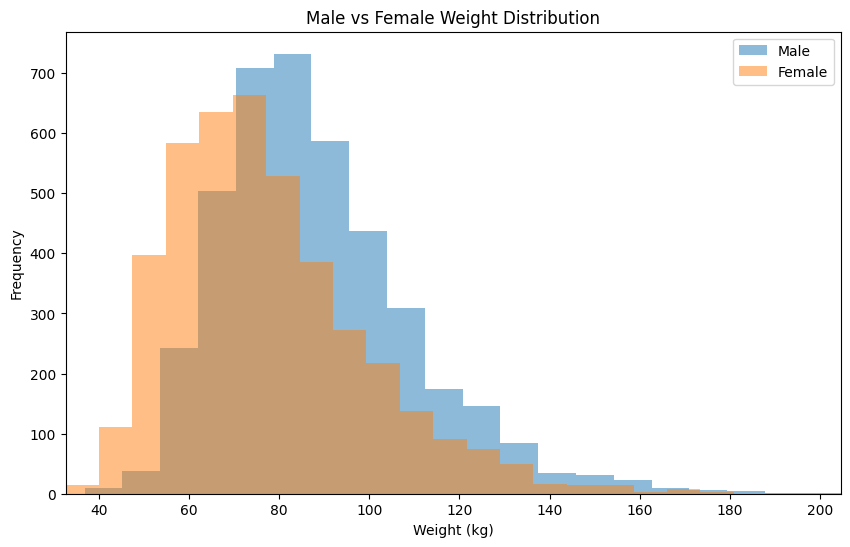

In [170]:
import matplotlib.pyplot as plt

xmin = min(male_df["Weight"].min(), female_df["Weight"].min())
xmax = max(male_df["Weight"].max(), female_df["Weight"].max())

plt.figure(figsize=(10,6))

plt.hist(
    male_df["Weight"],
    bins=20,
    alpha=0.5,
    label="Male"
)

plt.hist(
    female_df["Weight"],
    bins=20,
    alpha=0.5,
    label="Female"
)

plt.xlim(xmin, xmax)

plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.title("Male vs Female Weight Distribution")
plt.legend()

plt.show()

### Observation

The two histograms are plotted on the same axes, allowing direct comparison of the weight distributions. 

The male distribution is generally shifted towards higher weight values, indicating that male participants tend to weigh more on average. The overlap between the distributions shows that weight alone cannot completely distinguish between genders.


## 4. Comparing Male and Female Weights Using Boxplots

A box-and-whisker plot is used to compare the distribution of male and female weights.

By using matplotlib.pyplot.boxplot we will draw a box and whisker plot, with two boxes side by side, giving the male and female weights so that they can be compared to each other. The boxplot function can be fed with a list of two vectors like [female_weights, male_weights]

The boxplot displays:
- Median
- Quartiles (Q1 and Q3)
- Interquartile Range (IQR)
- Potential outliers

This allows a visual comparison of central tendency and variability between the two groups.

C:\Users\chada\AppData\Local\Temp\ipykernel_18720\2438684082.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([female_weights, male_weights],


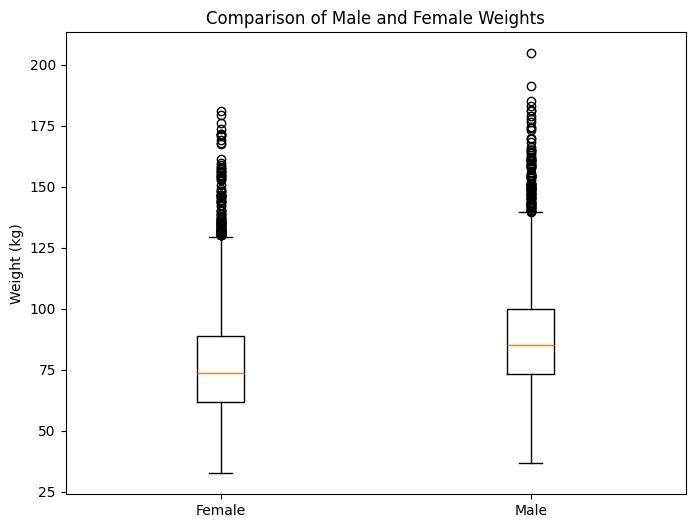

In [171]:
import matplotlib.pyplot as plt

female_weights = female_df["Weight"]
male_weights = male_df["Weight"]

plt.figure(figsize=(8,6))

plt.boxplot([female_weights, male_weights],
            labels=["Female", "Male"])

plt.title("Comparison of Male and Female Weights")
plt.ylabel("Weight (kg)")

plt.show()

### Observation

The boxplots allow direct comparison of the weight distributions for male and female participants.

The median weight of males is generally higher than that of females. The spread of the data can be assessed using the height of the boxes and whiskers. Individual points beyond the whiskers represent potential outliers, indicating unusually high or low weights.

## 5. Numerical Aggregates of Male and Female Weights

Descriptive statistics provide a numerical summary of a dataset and help us understand its main characteristics.

In this section, several statistical measures are calculated for male and female weights.

### Measures of Location
These statistics describe the central tendency of the data:
- Mean
- Median

### Measures of Dispersion
These statistics describe the spread or variability of the data:
- Standard Deviation
- Variance
- Range

### Measures of Shape
These statistics describe the distribution's shape:
- Skewness
- Kurtosis

The computed statistics will be used to compare the weight distributions of male and female participants and identify differences in central tendency, variability, and distribution shape.

In [125]:
from scipy.stats import skew, kurtosis

male_weights = male_df["Weight"]
female_weights = female_df["Weight"]

male_stats = {
    "Mean": male_weights.mean(),
    "Median": male_weights.median(),
    "Standard Deviation": male_weights.std(),
    "Variance": male_weights.var(),
    "Range": male_weights.max() - male_weights.min(),
    "Skewness": skew(male_weights),
    "Kurtosis": kurtosis(male_weights)
}

female_stats = {
    "Mean": female_weights.mean(),
    "Median": female_weights.median(),
    "Standard Deviation": female_weights.std(),
    "Variance": female_weights.var(),
    "Range": female_weights.max() - female_weights.min(),
    "Skewness": skew(female_weights),
    "Kurtosis": kurtosis(female_weights)
}

print("Male Weight Statistics")
for k, v in male_stats.items():
    print(f"{k}: {v:.2f}")

print("\nFemale Weight Statistics")
for k, v in female_stats.items():
    print(f"{k}: {v:.2f}")

Male Weight Statistics
Mean: 88.36
Median: 85.00
Standard Deviation: 21.42
Variance: 458.88
Range: 167.80
Skewness: 0.98
Kurtosis: 1.47

Female Weight Statistics
Mean: 77.40
Median: 73.60
Standard Deviation: 21.55
Variance: 464.19
Range: 148.30
Skewness: 1.03
Kurtosis: 1.40


### Comparison of Male and Female Weight Distributions

The numerical aggregates reveal several important differences between the male and female weight distributions.

1. The average (mean) weight of males is **88.36 kg**, which is higher than the average weight of females (**77.40 kg**). Similarly, the median weight of males (**85.00 kg**) is higher than that of females (**73.60 kg**), indicating that males generally weigh more than females.

2. The standard deviations are very similar (**21.42 kg for males** and **21.55 kg for females**), suggesting that both distributions exhibit a comparable level of variability. However, females show a slightly higher variance (**464.19**) than males (**458.88**).

3. The range of male weights (**167.80 kg**) is larger than the range of female weights (**148.30 kg**), indicating that male weights are spread over a wider interval.

4. Both distributions are **positively skewed (right-skewed)**, as indicated by skewness values greater than zero (**0.98 for males** and **1.03 for females**). This suggests the presence of a small number of participants with unusually high body weights.

5. The female weight distribution is slightly more skewed than the male distribution because its skewness value (**1.03**) is marginally higher than that of males (**0.98**).

6. Both distributions have positive kurtosis values (**1.47 for males** and **1.40 for females**), indicating heavier tails than a normal distribution and the presence of potential outliers.

### Conclusion

Both male and female weight distributions are right-skewed and contain some extreme high-weight observations. Males tend to weigh more on average, while both groups exhibit similar variability. The larger range observed among males suggests a wider spread of weights, whereas the slightly higher skewness among females indicates a marginally stronger influence of extreme high-weight observations.

## 6. Adding BMI as the Eighth Column to the female matrix

Body Mass Index (BMI) is a measure that relates weight to height.

BMI is calculated using weight in kilograms and height in meters. In this section, the BMI of each female participant is computed and appended as the eighth column of the female NumPy matrix.

## Body Mass Index (BMI)

BMI is a commonly used measure that relates body weight to height.

It is calculated as:

BMI = Weight (kg) / Height² (m²)

BMI helps assess whether an individual falls within a healthy weight range.

In [172]:
female_bmi = female[:, 0] / ((female[:, 1] / 100) ** 2)

In [173]:
import numpy as np

female = np.column_stack((female, female_bmi))

print(female.shape)

(4221, 8)


In [174]:
female[:5]

array([[ 97.1       , 160.2       ,  34.7       ,  40.8       ,
         35.8       , 126.1       , 117.9       ,  37.83504078],
       [ 91.1       , 152.7       ,  33.5       ,  33.        ,
         38.5       , 125.5       , 103.1       ,  39.06972037],
       [ 73.        , 161.2       ,  37.4       ,  38.        ,
         31.8       , 106.2       ,  92.        ,  28.09265496],
       [ 61.7       , 157.4       ,  38.        ,  34.7       ,
         29.        , 101.        ,  90.5       ,  24.90437849],
       [ 55.4       , 154.6       ,  34.6       ,  34.        ,
         28.3       ,  92.5       ,  73.2       ,  23.17879132]])

### Observation

The BMI values were successfully calculated and appended as the eighth column of the female matrix.

The updated matrix now contains the original seven body measurements along with BMI, providing an additional health-related indicator for each participant.

## 7. Creating the Standardized Female Matrix (zfemale)

The variables in the dataset are measured on different scales. To make them comparable, each column is standardized using the Z-score transformation.

Standardization is performed using the formula:

z = (x - μ) / σ

where:

- x = original value
- μ = mean of the column
- σ = standard deviation of the column

The resulting standardized dataset is stored in a new matrix called `zfemale`. After standardization, each column has a mean close to 0 and a standard deviation close to 1.

In [175]:
zfemale = (female - np.mean(female, axis=0)) / np.std(female, axis=0)

print(zfemale.shape)
zfemale[:5]

(4221, 8)


array([[ 0.91429508,  0.00895038, -0.56739463,  1.13298804,  0.55084546,
         1.08316157,  1.11578462,  0.9969677 ],
       [ 0.63577599, -1.05306843, -1.07893145, -1.29349161,  1.03221804,
         1.04475528,  0.265089  ,  1.15617483],
       [-0.2044233 ,  0.15055289,  0.5835632 ,  0.26194406, -0.1622991 ,
        -0.19064688, -0.37293272, -0.25927501],
       [-0.7289676 , -0.38753664,  0.83933161, -0.76464348, -0.66150029,
        -0.52350135, -0.45915188, -0.67039085],
       [-1.02141265, -0.78402366, -0.6100227 , -0.98240447, -0.78630059,
        -1.06759039, -1.45354609, -0.89289859]])

### Observation

The standardization process was successfully applied to all columns of the female dataset.

The resulting matrix `zfemale` contains standardized values with mean approximately equal to 0 and standard deviation approximately equal to 1. This allows meaningful comparison between variables that were originally measured on different scales.

## 8. Scatterplot Matrix and Correlation Analysis

A scatterplot matrix (pairplot) is used to visualize relationships among multiple variables simultaneously.

The following standardized female variables are analyzed:

- Height
- Weight
- Waist Circumference
- Hip Circumference
- BMI

In addition, Pearson's and Spearman's correlation coefficients are computed for all pairs of variables.

### Pearson Correlation
Measures the strength of a linear relationship between two variables.

### Spearman Correlation
Measures the strength of a monotonic relationship based on ranks and is less sensitive to outliers.

In [177]:
import pandas as pd

zfemale_df = pd.DataFrame(
    zfemale[:, [0, 1, 5, 6, 7]],
    columns=[
        "Weight",
        "Height",
        "Hip_Circumference",
        "Waist_Circumference",
        "BMI"
    ]
)

zfemale_df.head()

,Weight,Height,Hip_Circumference,Waist_Circumference,BMI
0,0.914295,0.008950,1.083162,1.115785,0.996968
1,0.635776,-1.053068,1.044755,0.265089,1.156175
2,-0.204423,0.150553,-0.190647,-0.372933,-0.259275
3,-0.728968,-0.387537,-0.523501,-0.459152,-0.670391
4,-1.021413,-0.784024,-1.067590,-1.453546,-0.892899


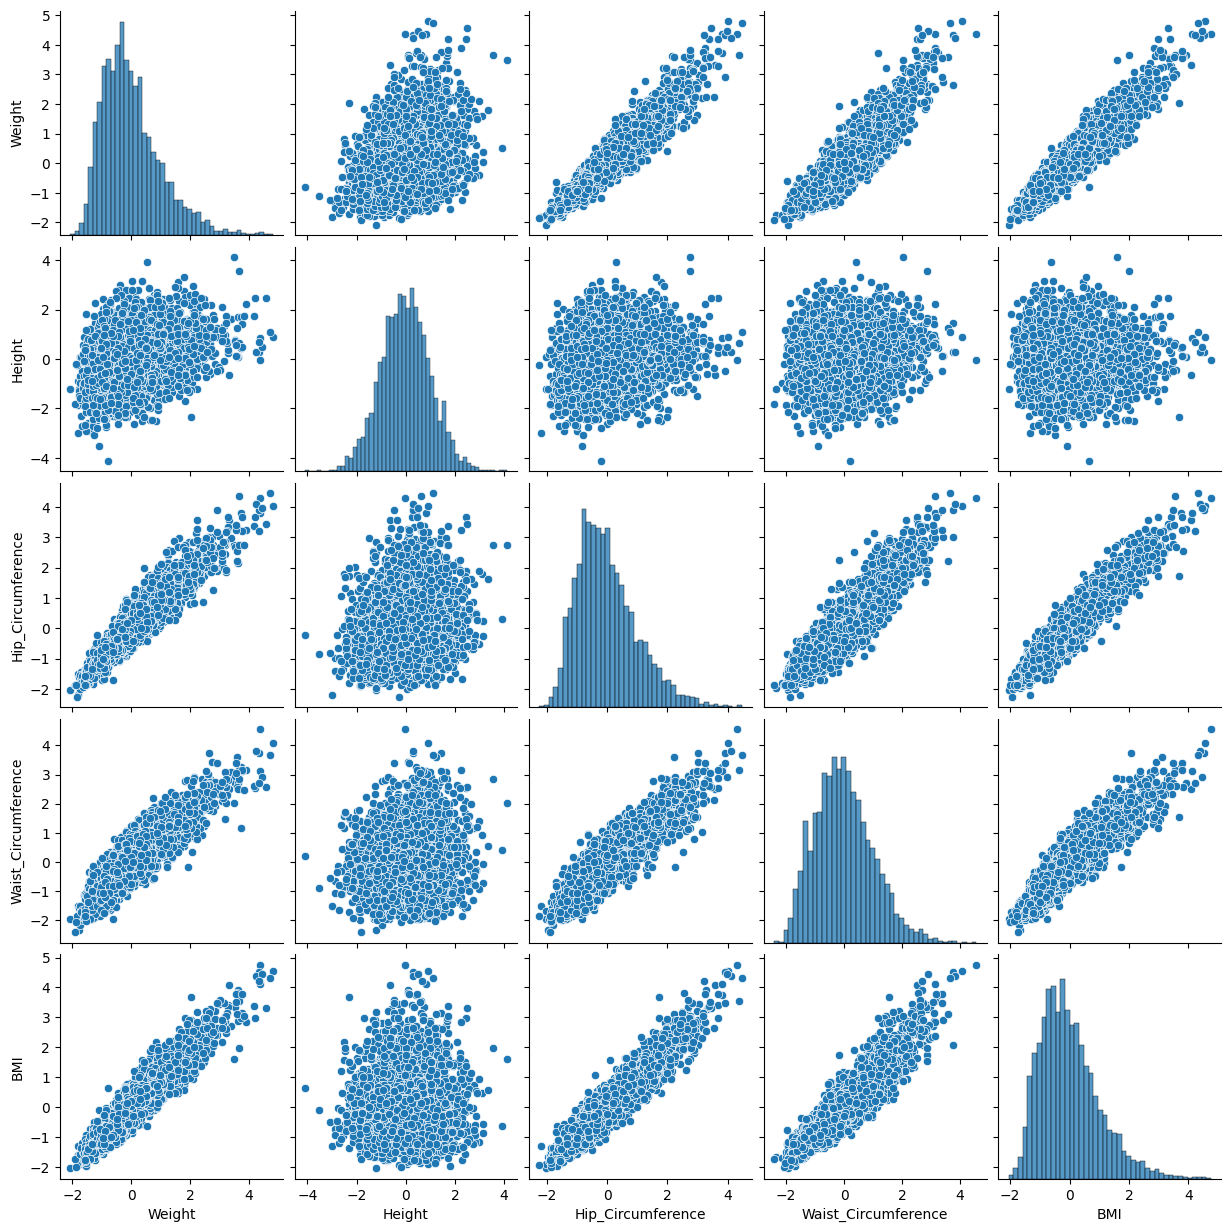

In [178]:
#Pairplot

import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(zfemale_df)

plt.show()

In [179]:
#Pearson correlation

pearson_corr = zfemale_df.corr(method="pearson")

pearson_corr

,Weight,Height,Hip_Circumference,Waist_Circumference,BMI
Weight,1.000000,0.345496,0.946553,0.904550,0.945900
Height,0.345496,1.000000,0.202895,0.126547,0.033077
Hip_Circumference,0.946553,0.202895,1.000000,0.897407,0.944199
Waist_Circumference,0.904550,0.126547,0.897407,1.000000,0.921198
BMI,0.945900,0.033077,0.944199,0.921198,1.000000


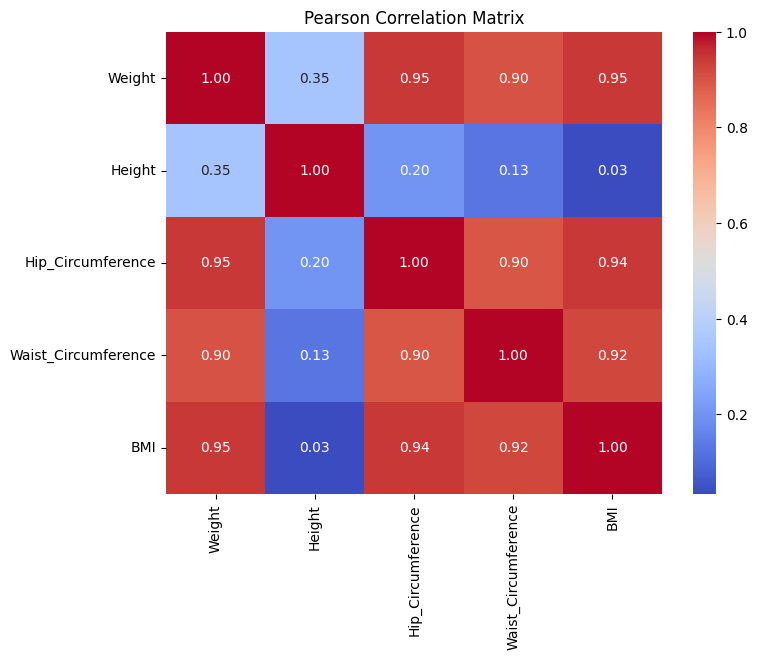

In [180]:
plt.figure(figsize=(8,6))

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Pearson Correlation Matrix")
plt.show()

In [181]:
#Spearman correlation

spearman_corr = zfemale_df.corr(method="spearman")

spearman_corr

,Weight,Height,Hip_Circumference,Waist_Circumference,BMI
Weight,1.000000,0.338860,0.946634,0.900169,0.937999
Height,0.338860,1.000000,0.205405,0.108587,0.019897
Hip_Circumference,0.946634,0.205405,1.000000,0.888037,0.934196
Waist_Circumference,0.900169,0.108587,0.888037,1.000000,0.923114
BMI,0.937999,0.019897,0.934196,0.923114,1.000000


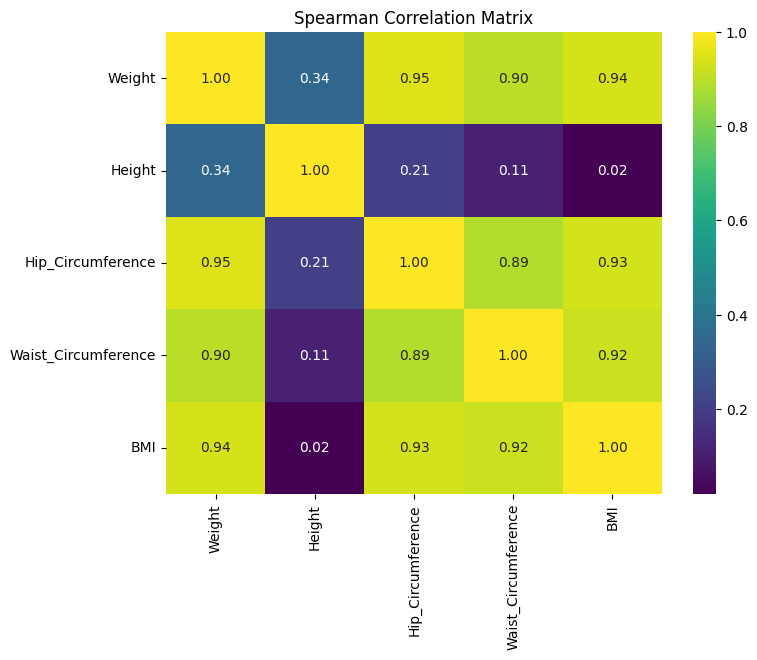

In [193]:
plt.figure(figsize=(8,6))

sns.heatmap(
    spearman_corr,
    annot=True,
    cmap="viridis",
    fmt=".2f"
)

plt.title("Spearman Correlation Matrix")
plt.show()

### Interpretation of Results

The scatterplot matrix and correlation analysis reveal several important relationships among the body measurements of female participants.

1. Weight and Hip Circumference exhibit a very strong positive correlation (Pearson = 0.947, Spearman = 0.947). This indicates that participants with higher body weight generally tend to have larger hip circumferences.

2. Weight and BMI also show a very strong positive correlation (Pearson = 0.946, Spearman = 0.938). This is expected because BMI is directly calculated using weight and height.

3. Weight and Waist Circumference are strongly correlated (Pearson = 0.905, Spearman = 0.900), suggesting that increases in body weight are associated with increases in waist size.

4. Hip Circumference and BMI have a very strong positive relationship (Pearson = 0.944, Spearman = 0.934), indicating that BMI increases as hip circumference increases.

5. Waist Circumference and BMI are also highly correlated (Pearson = 0.921, Spearman = 0.923), showing that waist circumference is a strong indicator of body composition.

6. Height exhibits relatively weak correlations with the other variables. The strongest relationship involving height is with weight (Pearson = 0.345, Spearman = 0.339), while the correlation between height and BMI is extremely weak (Pearson = 0.033, Spearman = 0.020).

7. The Pearson and Spearman coefficients are very similar for all variable pairs. This suggests that the relationships are both linear and monotonic, and that the data does not contain strong nonlinear patterns.

### Conclusion

The analysis demonstrates that Weight, Hip Circumference, Waist Circumference, and BMI are highly interconnected measurements. Height shows comparatively weaker relationships with the remaining variables. The close agreement between Pearson and Spearman correlation coefficients indicates consistent and stable associations among the analyzed body measurements.

## 9. Adding Waist-to-Height Ratio and Waist-to-Hip Ratio

Two additional body proportion indicators are computed and appended to the male and female matrices.

### Waist-to-Height Ratio (WHtR)

WHtR = Waist Circumference / Height

This ratio measures waist size relative to height.

### Waist-to-Hip Ratio (WHR)

WHR = Waist Circumference / Hip Circumference

This ratio measures the relationship between waist and hip size and is commonly used to assess body fat distribution.

In [205]:
import numpy as np

# Male ratios
male_whtr = male[:, 6] / male[:, 1]
male_whr = male[:, 6] / male[:, 5]

# Female ratios
female_whtr = female[:, 6] / female[:, 1]
female_whr = female[:, 6] / female[:, 5]

# Add ratios as new columns
male = np.column_stack((male, male_whtr, male_whr))
female = np.column_stack((female, female_whtr, female_whr))

print("Male Shape:", male.shape)
print("Female Shape:", female.shape)


Male Shape: (4081, 15)
Female Shape: (4221, 46)


In [206]:
# Display first 5 rows

print("Male Dataset")
print(male[:5])

print("\nFemale Dataset")
print(female[:5])

Male Dataset
[[ 98.8        182.3         42.          40.1         38.2
  108.2        120.4          0.66044981   1.11275416   0.66044981
    1.11275416   0.66044981   1.11275416   0.66044981   1.11275416]
 [ 74.3        184.2         41.1         41.          30.2
   94.5         86.8          0.47122693   0.91851852   0.47122693
    0.91851852   0.47122693   0.91851852   0.47122693   0.91851852]
 [103.7        185.3         47.          44.          32.
  107.8        109.6          0.59147329   1.01669759   0.59147329
    1.01669759   0.59147329   1.01669759   0.59147329   1.01669759]
 [ 86.         167.8         39.5         38.4         29.
  106.4        108.3          0.6454112    1.01785714   0.6454112
    1.01785714   0.6454112    1.01785714   0.6454112    1.01785714]
 [ 99.4        181.6         40.4         39.9         36.
  120.2        107.           0.58920705   0.89018303   0.58920705
    0.89018303   0.58920705   0.89018303   0.58920705   0.89018303]]

Female Dataset

### Observation

The Waist-to-Height Ratio (WHtR) and Waist-to-Hip Ratio (WHR) were successfully calculated and added as new columns to both the male and female datasets.

These derived ratios provide additional information about body proportions that cannot be obtained from weight and height alone.

- WHtR relates waist circumference to height and helps assess abdominal fat relative to body size.
- WHR compares waist circumference to hip circumference and provides insight into body fat distribution patterns.

By adding these variables, the dataset becomes more informative and allows for a deeper analysis of body composition differences between male and female participants.

## 10. Comparison of Waist-to-Height Ratio and Waist-to-Hip Ratio using box-and-whisker plot

A box-and-whisker plot is used to compare the distributions of:

- Female Waist-to-Height Ratio (WHtR)
- Male Waist-to-Height Ratio (WHtR)
- Female Waist-to-Hip Ratio (WHR)
- Male Waist-to-Hip Ratio (WHR)

The boxplots allow comparison of central tendency, variability, and potential outliers across the four distributions.

In [207]:
for name, arr in [
    ("Female WHtR", female[:, -2]),
    ("Male WHtR", male[:, -2]),
    ("Female WHR", female[:, -1]),
    ("Male WHR", male[:, -1]),
]:
    print(f"\n{name}")
    print("Min:", np.min(arr))
    print("Q1:", np.percentile(arr, 25))
    print("Median:", np.median(arr))
    print("Q3:", np.percentile(arr, 75))
    print("Max:", np.max(arr))


Female WHtR
Min: 0.37507418397626113
Q1: 0.5374554102259216
Median: 0.6097414311485267
Q3: 0.6845052893590542
Max: 1.1131957473420888

Male WHtR
Min: 0.3661522086216072
Q1: 0.5215493726132023
Median: 0.5819174757281553
Q3: 0.6446821152703506
Max: 0.9737742303306728

Female WHR
Min: 0.6627423822714681
Q1: 0.8506429277942632
Median: 0.9028871391076116
Q3: 0.9515291402192729
Max: 1.1652631578947368

Male WHR
Min: 0.7262313860252004
Q1: 0.9192782526115859
Median: 0.9767195767195767
Q3: 1.0246791707798617
Max: 1.2383720930232558


C:\Users\chada\AppData\Local\Temp\ipykernel_18720\2574990794.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


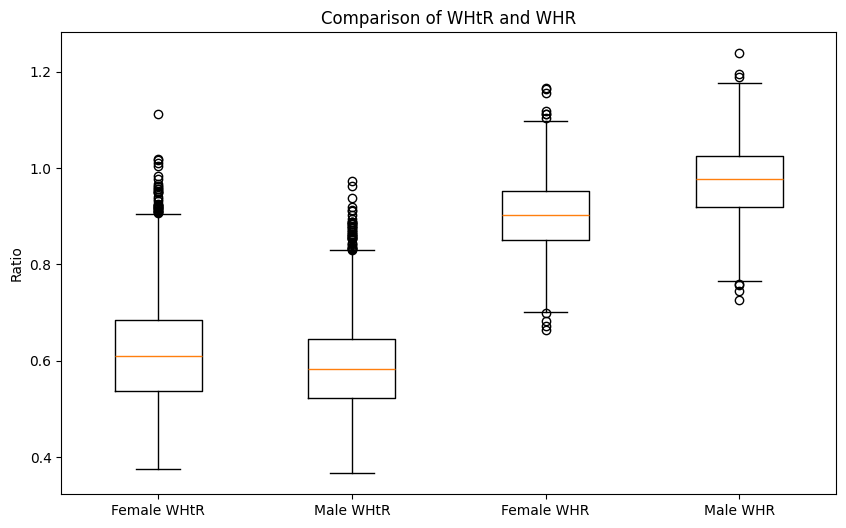

In [208]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.boxplot([
    female[:, -2],   # Female WHtR
    male[:, -2],     # Male WHtR
    female[:, -1],   # Female WHR
    male[:, -1]      # Male WHR
],
labels=[
    "Female WHtR",
    "Male WHtR",
    "Female WHR",
    "Male WHR"
])

plt.title("Comparison of WHtR and WHR")
plt.ylabel("Ratio")

plt.show()

### Interpretation of the Boxplots

The boxplots compare the distributions of Waist-to-Height Ratio (WHtR) and Waist-to-Hip Ratio (WHR) for male and female participants.

1. The median WHtR for females (0.610) is higher than that of males (0.582). This suggests that, relative to their height, female participants tend to have slightly larger waist circumferences.

2. The interquartile range (IQR) for female WHtR (0.537–0.685) is slightly wider than that of males (0.522–0.645), indicating greater variability among female participants.

3. Female WHtR also exhibits a higher maximum value (1.113) compared to males (0.974), suggesting the presence of more extreme observations.

4. The median WHR for males (0.977) is higher than that of females (0.903). This indicates that male participants generally have larger waist circumferences relative to their hip circumferences.

5. The male WHR distribution is shifted toward higher values, reflecting differences in body shape and fat distribution between males and females.

6. The interquartile ranges of WHR are similar for both groups, although males show slightly higher values throughout the distribution.

7. Both WHtR and WHR distributions contain some extreme values, as indicated by the large maximum values relative to their upper quartiles.

### Conclusion

The analysis reveals clear gender differences in body proportions. Female participants tend to have higher Waist-to-Height Ratios, while male participants tend to have higher Waist-to-Hip Ratios. These findings suggest differences in body shape and fat distribution patterns between the two groups.

## 11. Advantages and Disadvantages of BMI, Waist-to-Height Ratio, and Waist-to-Hip Ratio

### 1. Body Mass Index (BMI)

#### Advantages
- Simple and easy to calculate using only height and weight.
- Widely used in health and medical research.
- Useful for identifying underweight, normal weight, overweight, and obesity categories.
- Allows comparison across large populations.

#### Disadvantages
- Does not distinguish between muscle mass and body fat.
- May classify muscular individuals as overweight or obese.
- Does not provide information about fat distribution in the body.
- Can sometimes underestimate health risks associated with abdominal fat.

---

### 2. Waist-to-Height Ratio (WHtR)

#### Advantages
- Takes abdominal fat into account, which is an important health indicator.
- Easy to calculate using waist circumference and height.
- Often considered a better predictor of cardiovascular and metabolic health risks than BMI.
- Applicable across different age groups and populations.

#### Disadvantages
- Requires accurate waist circumference measurements.
- Does not differentiate between muscle and fat mass.
- Measurement techniques may vary between observers.

---

### 3. Waist-to-Hip Ratio (WHR)

#### Advantages
- Measures body fat distribution rather than overall body size.
- Useful for identifying central (abdominal) obesity.
- Can help assess the risk of heart disease and metabolic disorders.
- Provides information that BMI alone cannot capture.

#### Disadvantages
- Requires two body measurements, increasing the possibility of measurement errors.
- Does not directly indicate overall body fat percentage.
- Individuals with similar WHR values may have very different body compositions.
- Interpretation can vary across age groups and populations.

---

### Conclusion

Each measure provides different information about body composition and health. BMI is useful for assessing overall body size, WHtR helps evaluate abdominal fat relative to height, and WHR provides insight into fat distribution. Using these measures together offers a more comprehensive assessment than relying on any single indicator alone.

## 12. Females with the Lowest and Highest BMI

To better understand how body measurements vary with BMI, the five participants with the lowest BMI and the five participants with the highest BMI are identified.

The standardized measurements (z-scores) of these participants are then examined and compared.

In [209]:
import numpy as np

# Sort participants by BMI
sorted_idx = np.argsort(female[:, 7])

# 5 lowest BMI
lowest_bmi_idx = sorted_idx[:5]

# 5 highest BMI
highest_bmi_idx = sorted_idx[-5:]

# Combine indices
selected_idx = np.concatenate((lowest_bmi_idx, highest_bmi_idx))

# Print standardized measurements
print(zfemale[selected_idx])

[[-2.07978523 -1.22299143 -1.5478402  -1.16905675 -2.1947611  -2.0405496
  -1.94212128 -2.05024028]
 [-1.88017988 -0.18929313 -1.71835247  0.38637892 -2.4443617  -1.85491922
  -2.05708015 -1.99487987]
 [-1.53667299  1.80730222  0.62619127  0.5730312  -2.26607556 -1.6756899
  -1.7064556  -1.97088383]
 [-1.843044   -0.26009438 -0.22637009  0.51081377 -2.30173278 -2.25178417
  -1.85590213 -1.94177591]
 [-1.61094475  0.88688592 -0.09848588  0.47970506 -2.21258971 -1.82931504
  -1.71220354 -1.89319577]
 [ 4.2472403   0.29215539  1.86240524 -0.98240447  2.3693641   4.10445598
   3.81731803  4.39649161]
 [ 4.45612963  0.50455915  1.69189297 -1.13794804  3.34993787  3.98283607
   2.90339503  4.46201122]
 [ 4.34936397  0.27799514  2.84285081  1.94181459  4.36616887  3.9188256
   3.75409065  4.51466896]
 [ 4.8042785   0.88688592  2.11817365  1.81737973  3.77782461  4.02124236
   4.08172343  4.54270932]
 [ 4.36328993 -0.03353037 -0.05585782 -0.17357792  2.77942222  4.31569054
   4.57029862  4.762

In [210]:
import pandas as pd

columns = [
    "Weight",
    "Height",
    "Upper_Arm_Length",
    "Upper_Leg_Length",
    "Arm_Circumference",
    "Hip_Circumference",
    "Waist_Circumference",
    "BMI"
]

selected_df = pd.DataFrame(
    zfemale[selected_idx],
    columns=columns
)

selected_df

,Weight,Height,Upper_Arm_Length,Upper_Leg_Length,Arm_Circumference,Hip_Circumference,Waist_Circumference,BMI
0,-2.079785,-1.222991,-1.547840,-1.169057,-2.194761,-2.040550,-1.942121,-2.050240
1,-1.880180,-0.189293,-1.718352,0.386379,-2.444362,-1.854919,-2.057080,-1.994880
2,-1.536673,1.807302,0.626191,0.573031,-2.266076,-1.675690,-1.706456,-1.970884
3,-1.843044,-0.260094,-0.226370,0.510814,-2.301733,-2.251784,-1.855902,-1.941776
4,-1.610945,0.886886,-0.098486,0.479705,-2.212590,-1.829315,-1.712204,-1.893196
5,4.247240,0.292155,1.862405,-0.982404,2.369364,4.104456,3.817318,4.396492
6,4.456130,0.504559,1.691893,-1.137948,3.349938,3.982836,2.903395,4.462011
7,4.349364,0.277995,2.842851,1.941815,4.366169,3.918826,3.754091,4.514669
8,4.804279,0.886886,2.118174,1.817380,3.777825,4.021242,4.081723,4.542709
9,4.363290,-0.033530,-0.055858,-0.173578,2.779422,4.315691,4.570299,4.762433


### Interpretation

The standardized body measurements of the five participants with the lowest BMI and the five participants with the highest BMI show clear differences.

1. The participants with the lowest BMI have strongly negative BMI z-scores (approximately -1.89 to -2.05), indicating that their BMI values are far below the average BMI of the female population.

2. These low-BMI participants also exhibit negative z-scores for weight, arm circumference, hip circumference, and waist circumference. This indicates that they are generally lighter and have smaller body measurements than the average participant.

3. Some low-BMI participants have above-average heights despite having low body weights. This demonstrates how taller individuals with relatively low body weight can have low BMI values.

4. The participants with the highest BMI have extremely large positive BMI z-scores (approximately 4.40 to 4.76), indicating that their BMI values are far above the population average.

5. These high-BMI participants also have very large positive z-scores for weight, waist circumference, hip circumference, and arm circumference. In many cases, these values exceed 4 standard deviations above the mean, highlighting their exceptionally large body measurements.

6. Height varies much less than weight and circumference measurements among both groups. This suggests that BMI is influenced more strongly by body mass and body circumferences than by height.

7. Waist circumference and hip circumference show particularly large positive z-scores among high-BMI individuals, reinforcing the strong correlations observed earlier between BMI, weight, waist circumference, and hip circumference.

### Conclusion

The comparison clearly demonstrates that BMI is strongly associated with body size measurements. Individuals with low BMI tend to have smaller weights and body circumferences, whereas individuals with high BMI tend to have substantially larger weights, waists, hips, and arm circumferences. The results confirm the relationships identified in the correlation and scatterplot analyses performed earlier in the project.

# Executive Summary

This project analyzes anthropometric data from the National Health and Nutrition Examination Survey (NHANES) dataset using Python, NumPy, Pandas, Matplotlib, and Seaborn.

The objective of the study is to compare body measurements of adult male and female participants and investigate relationships among various physical characteristics. The analysis includes data loading, data preprocessing, descriptive statistics, visualization, standardization, correlation analysis, and the computation of additional body composition indicators.

Key analyses performed in this project include:

- Comparison of male and female body measurements using descriptive statistics.
- Visualization of weight distributions through histograms and boxplots.
- Calculation and analysis of Body Mass Index (BMI).
- Computation of Waist-to-Height Ratio (WHtR) and Waist-to-Hip Ratio (WHR).
- Standardization of variables using Z-scores.
- Scatterplot matrix (pairplot) analysis of standardized variables.
- Pearson and Spearman correlation analysis to identify relationships among body measurements.
- Identification and comparison of participants with the lowest and highest BMI values.
- Interpretation of body composition indicators and their advantages and limitations.

The results show strong relationships between weight, BMI, waist circumference, and hip circumference. Correlation analysis indicates that body size measurements are highly interconnected, while height exhibits comparatively weaker relationships with the other variables. The study demonstrates how exploratory data analysis techniques can be applied to real-world health datasets to extract meaningful insights and support data-driven understanding of human body measurements.

# Key Learning Outcomes

Through this project, the following concepts and skills were learned and applied:

1. Loading and processing real-world datasets using NumPy and Pandas.

2. Performing data cleaning and preprocessing to prepare data for analysis.

3. Computing descriptive statistics such as mean, median, variance, standard deviation, skewness, and kurtosis.

4. Visualizing data distributions using histograms and boxplots.

5. Comparing male and female body measurements using graphical and statistical techniques.

6. Calculating derived health indicators such as:
   - Body Mass Index (BMI)
   - Waist-to-Height Ratio (WHtR)
   - Waist-to-Hip Ratio (WHR)

7. Standardizing variables using Z-score transformation to enable meaningful comparisons across different measurement scales.

8. Using scatterplot matrices (pairplots) to explore relationships among multiple variables.

9. Applying Pearson and Spearman correlation analysis to measure linear and monotonic relationships between body measurements.

10. Identifying and interpreting outliers and extreme observations using statistical methods and visualizations.

11. Understanding the strengths and limitations of BMI, WHtR, and WHR as indicators of body composition.

12. Developing the ability to extract meaningful insights from health-related datasets using exploratory data analysis techniques.

# Conclusion

This project successfully analyzed body measurement data from the NHANES dataset and compared anthropometric characteristics of adult male and female participants.

The analysis revealed that males generally have higher average values for weight, height, waist circumference, and hip circumference than females. Histogram and boxplot visualizations highlighted the distribution patterns and variability present in the data.

Correlation analysis showed strong positive relationships between weight, BMI, waist circumference, and hip circumference, indicating that these measurements tend to increase together. In contrast, height exhibited relatively weaker correlations with the other variables.

The computation of BMI, Waist-to-Height Ratio (WHtR), and Waist-to-Hip Ratio (WHR) provided additional insights into body composition and body fat distribution. The comparison of participants with the lowest and highest BMI values further demonstrated the strong association between BMI and body measurements such as weight, waist circumference, and hip circumference.

Standardization using Z-scores enabled meaningful comparison of variables measured on different scales and facilitated multivariate analysis through scatterplot matrices and correlation studies.

Overall, this project demonstrates how statistical analysis and data visualization techniques can be used to explore real-world health datasets, identify meaningful patterns, and gain valuable insights into human body measurements and body composition.

# References

1. National Health and Nutrition Examination Survey (NHANES), Centers for Disease Control and Prevention (CDC).
   https://www.cdc.gov/nchs/nhanes/

2. NHANES Body Measures Data Documentation.
   https://wwwn.cdc.gov/nchs/nhanes/

3. Gagolewski, M. Teaching Data Repository (NHANES Dataset Excerpts).
   https://github.com/gagolews/teaching-data

4. NumPy Documentation.
   https://numpy.org/doc/

5. Pandas Documentation.
   https://pandas.pydata.org/docs/

6. Matplotlib Documentation.
   https://matplotlib.org/stable/users/index.html

7. Seaborn Documentation.
   https://seaborn.pydata.org/

8. SciPy Statistics Documentation.
   https://docs.scipy.org/doc/scipy/reference/stats.html

9. Body Mass Index (BMI) Information - World Health Organization (WHO).
   https://www.who.int

10. Waist-to-Height Ratio and Waist-to-Hip Ratio Health Indicators.
    Ashwell, M., & Gibson, S. (2016).
    Waist-to-height ratio as an indicator of health risk.

11. Pearson Correlation Coefficient Documentation.
    https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html

12. Spearman Rank Correlation Documentation.
    https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html

## Acknowledgement

The NHANES dataset used in this project is provided by the National Center for Health Statistics (NCHS), Centers for Disease Control and Prevention (CDC). The analysis was performed using Python and its data science ecosystem, including NumPy, Pandas, Matplotlib, Seaborn, and SciPy.